# Certificate Transparency Pattern Analysis

Explore synthetic certificate records to find unusual fingerprint and subject-alternative-name reuse.

**Safety and scope:** This notebook uses deterministic synthetic data and makes no network requests. Its results are analytical leads, not attribution or identity claims.

## Goal

Surface certificate clusters that may connect infrastructure while preserving uncertainty and context.


## Setup

The workflow runs offline with NumPy and Pandas. Parameters and source-like fields are visible so the analysis can be reviewed and rerun.

### Key Assumptions

- All records are synthetic and contain no real people or infrastructure.
- Scores prioritize review; they do not prove ownership, intent, identity, or location.
- Real use requires documented authority, provenance, source terms, and retention limits.


In [1]:
import numpy as np
import pandas as pd

SEED = 88
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 70)


## Steps

### 1. Create bounded synthetic observations


In [2]:
certificate_count = 96
certificates = pd.DataFrame({
    "certificate_id": [f"cert-{index:04d}" for index in range(certificate_count)],
    "fingerprint_group": rng.choice([f"fp-{index:02d}" for index in range(18)], certificate_count),
    "issuer": rng.choice(["CA-One", "CA-Two", "CA-Three"], certificate_count),
    "san_count": rng.integers(1, 18, certificate_count),
    "validity_days": rng.choice([30, 90, 180, 365], certificate_count, p=[0.10, 0.55, 0.10, 0.25]),
    "domain_age_days": rng.integers(1, 1500, certificate_count),
})
certificates["new_domain"] = (certificates["domain_age_days"] < 30).astype(int)
print(certificates.head(6).to_string(index=False))


certificate_id fingerprint_group   issuer  san_count  validity_days  domain_age_days  new_domain
     cert-0000             fp-09 CA-Three         13            365               56           0
     cert-0001             fp-03   CA-Two          1            180              958           0
     cert-0002             fp-16   CA-Two          2             90             1464           0
     cert-0003             fp-12   CA-One         12             90              612           0
     cert-0004             fp-12   CA-One          2             30              674           0
     cert-0005             fp-12   CA-Two         14             90              966           0


### 2. Analyze and rank the observations


In [3]:
fingerprint_summary = (
    certificates.groupby("fingerprint_group", as_index=False)
    .agg(certificates=("certificate_id", "count"), issuers=("issuer", "nunique"), median_sans=("san_count", "median"), new_domains=("new_domain", "sum"))
)
fingerprint_summary["pattern_score"] = (
    0.50 * np.minimum(fingerprint_summary["certificates"] / 8, 1)
    + 0.30 * np.minimum(fingerprint_summary["new_domains"] / 3, 1)
    + 0.20 * np.minimum(fingerprint_summary["median_sans"] / 12, 1)
).round(3)
ranked_fingerprints = fingerprint_summary.sort_values("pattern_score", ascending=False)
print(ranked_fingerprints.head(8).to_string(index=False))


fingerprint_group  certificates  issuers  median_sans  new_domains  pattern_score
            fp-12            10        3         10.0            1          0.767
            fp-02             8        3         10.5            0          0.675
            fp-04             6        3         12.5            1          0.675
            fp-05             9        3         10.0            0          0.667
            fp-03             7        3         11.0            0          0.621
            fp-08             8        2          7.0            0          0.617
            fp-17             6        2         12.0            0          0.575
            fp-11             5        2          7.0            1          0.529


## Visual Insights & ML Extension

This section adds a polished visual story and a project-appropriate machine-learning extension while preserving the original transparent score or aggregation. Supervised labels are synthetic evaluation aids; unsupervised clusters and anomalies are review leads only.

**Interpretation boundary:** these results do not prove identity, ownership, intent, attribution, or location. Real use requires lawful authority, source provenance, independent corroboration, and retention controls.


 clusters  silhouette  inertia
        2       0.285   56.321
        3       0.292   40.670
        4       0.280   31.391
        5       0.282   25.009
        6       0.292   19.271

Analyst takeaways:
- Silhouette analysis selects 3 behavioral clusters.
- Cluster 0 has the highest average review score.
- Certificate reuse is contextual evidence and requires provider, CDN, and managed-platform baselines.
/Users/vinaysheelkapgate/Documents/Codex/2026-08-12/can/work/cybersecurity-analytics/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/Users/vinaysheelkapgate/Documents/Codex/2026-08-12/can/work/cybersecurity-analytics/.venv/lib/python3.12/site-packages/jobli

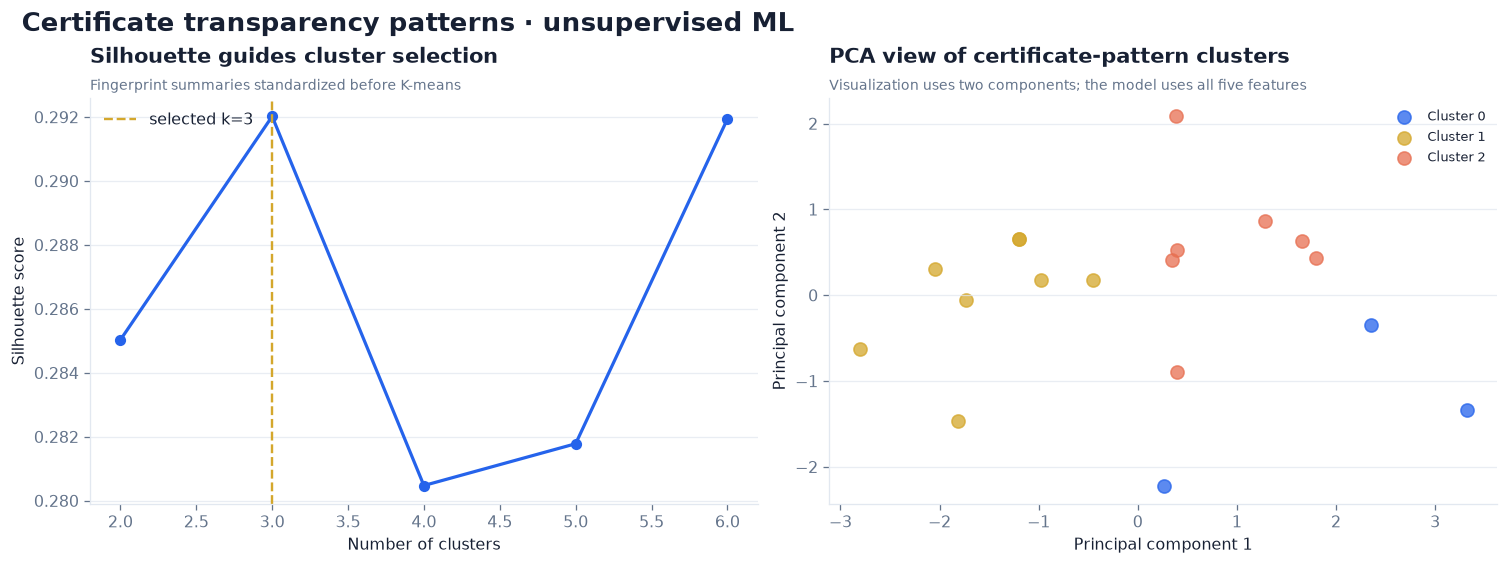

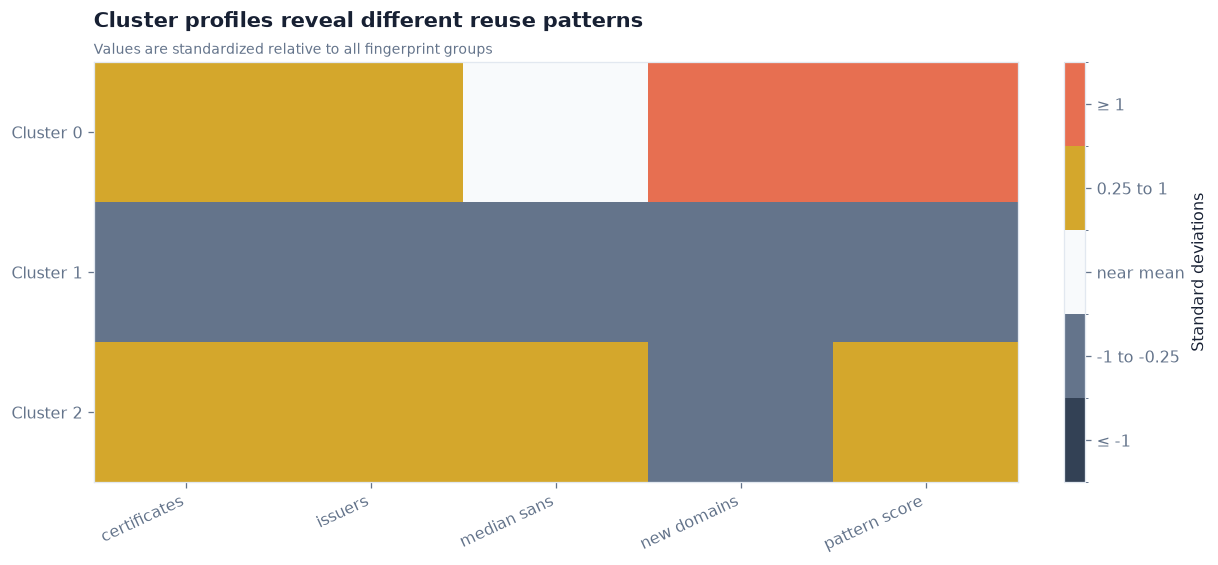

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, mean_absolute_error, r2_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 88)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def compare_binary_models(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows, probabilities, fitted = [], {}, {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

certificate_features = fingerprint_summary[["certificates", "issuers", "median_sans", "new_domains", "pattern_score"]]
certificate_scaled = StandardScaler().fit_transform(certificate_features)
trials, fitted = [], {}
for candidate_k in range(2, 7):
    model = KMeans(n_clusters=candidate_k, n_init=30, random_state=SEED)
    labels = model.fit_predict(certificate_scaled)
    trials.append({"clusters": candidate_k, "silhouette": silhouette_score(certificate_scaled, labels), "inertia": model.inertia_})
    fitted[candidate_k] = (model, labels)
certificate_diagnostics = pd.DataFrame(trials)
selected_k = int(certificate_diagnostics.loc[certificate_diagnostics["silhouette"].idxmax(), "clusters"])
_, certificate_cluster = fitted[selected_k]
certificate_projection = PCA(n_components=2, random_state=SEED).fit_transform(certificate_scaled)
fingerprint_ml = fingerprint_summary.assign(ml_cluster=certificate_cluster)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
axes[0].plot(certificate_diagnostics["clusters"], certificate_diagnostics["silhouette"], marker="o", linewidth=2, color=PALETTE["blue"])
axes[0].axvline(selected_k, linestyle="--", color=PALETTE["gold"], label=f"selected k={selected_k}")
axes[0].legend(frameon=False)
polish_axis(axes[0], "Silhouette guides cluster selection", "Fingerprint summaries standardized before K-means", "Number of clusters", "Silhouette score")

colors = [PALETTE["blue"], PALETTE["gold"], PALETTE["orange"], PALETTE["olive"], PALETTE["pink"], PALETTE["muted"]]
for cluster_id in range(selected_k):
    member = certificate_cluster == cluster_id
    axes[1].scatter(certificate_projection[member, 0], certificate_projection[member, 1], s=68, alpha=0.75, color=colors[cluster_id], label=f"Cluster {cluster_id}")
axes[1].legend(frameon=False, fontsize=8)
polish_axis(axes[1], "PCA view of certificate-pattern clusters", "Visualization uses two components; the model uses all five features", "Principal component 1", "Principal component 2")
fig.suptitle("Certificate transparency patterns · unsupervised ML", fontsize=16, fontweight="bold", x=0.01, ha="left")

cluster_profiles = fingerprint_ml.groupby("ml_cluster")[certificate_features.columns].mean()
profile_z = (cluster_profiles - certificate_features.mean()) / certificate_features.std()
fig, ax = plt.subplots(figsize=(10.5, 4.8), constrained_layout=True)
from matplotlib.colors import BoundaryNorm, ListedColormap
profile_colors = ListedColormap(["#334155", "#64748B", "#F8FAFC", "#D4A72C", "#E76F51"])
profile_norm = BoundaryNorm([-2.5, -1.0, -0.25, 0.25, 1.0, 2.5], profile_colors.N, clip=True)
image = ax.imshow(profile_z, cmap=profile_colors, norm=profile_norm, aspect="auto")
ax.set_xticks(range(len(profile_z.columns)), profile_z.columns.str.replace("_", " "), rotation=25, ha="right")
ax.set_yticks(range(len(profile_z)), [f"Cluster {value}" for value in profile_z.index])
ax.set_title("Cluster profiles reveal different reuse patterns", loc="left", pad=22)
ax.text(0, 1.02, "Values are standardized relative to all fingerprint groups", transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
colorbar = fig.colorbar(image, ax=ax, ticks=[-1.75, -0.625, 0, 0.625, 1.75])
colorbar.ax.set_yticklabels(["≤ -1", "-1 to -0.25", "near mean", "0.25 to 1", "≥ 1"])
colorbar.set_label("Standard deviations")

print(certificate_diagnostics.round(3).to_string(index=False))
print("\nAnalyst takeaways:")
print(f"- Silhouette analysis selects {selected_k} behavioral clusters.")
print(f"- Cluster {int(cluster_profiles['pattern_score'].idxmax())} has the highest average review score.")
print("- Certificate reuse is contextual evidence and requires provider, CDN, and managed-platform baselines.")


## Checks

Run deterministic integrity and reasonableness checks.


In [5]:
assert certificates["certificate_id"].is_unique
assert ranked_fingerprints["pattern_score"].between(0, 1).all()
assert ranked_fingerprints["certificates"].sum() == certificate_count
print("Checks passed; certificate reuse is contextual evidence, not proof of control.")


Checks passed; certificate reuse is contextual evidence, not proof of control.


## Next Steps

- Compare first-seen dates across transparent certificate sources.
- Separate CDN and managed-platform reuse before review.
